In [8]:
import numpy as np
import matplotlib.pyplot as plt
import re
from Bio import SeqIO

In [9]:
def load_mtDNA():
    """Загрузка ваших митохондриальных геномов"""
    homo = next(SeqIO.parse('homo_sapiens.fasta', 'fasta'))
    nean = next(SeqIO.parse('neanderthal.fasta', 'fasta'))
    
    return {
        'homo': str(homo.seq),
        'nean': str(nean.seq),
        'homo_len': len(homo.seq),
        'nean_len': len(nean.seq)
    }

data = load_mtDNA()
print(f'Homo sapiens: {data["homo_len"]} bp')
print(f'Neanderthal: {data["nean_len"]} bp')


Homo sapiens: 16569 bp
Neanderthal: 16565 bp


Загрузка геномов...
Homo sapiens mtDNA: 16,569 bp
Neanderthal mtDNA: 16,565 bp
Вычисление DotPlot...


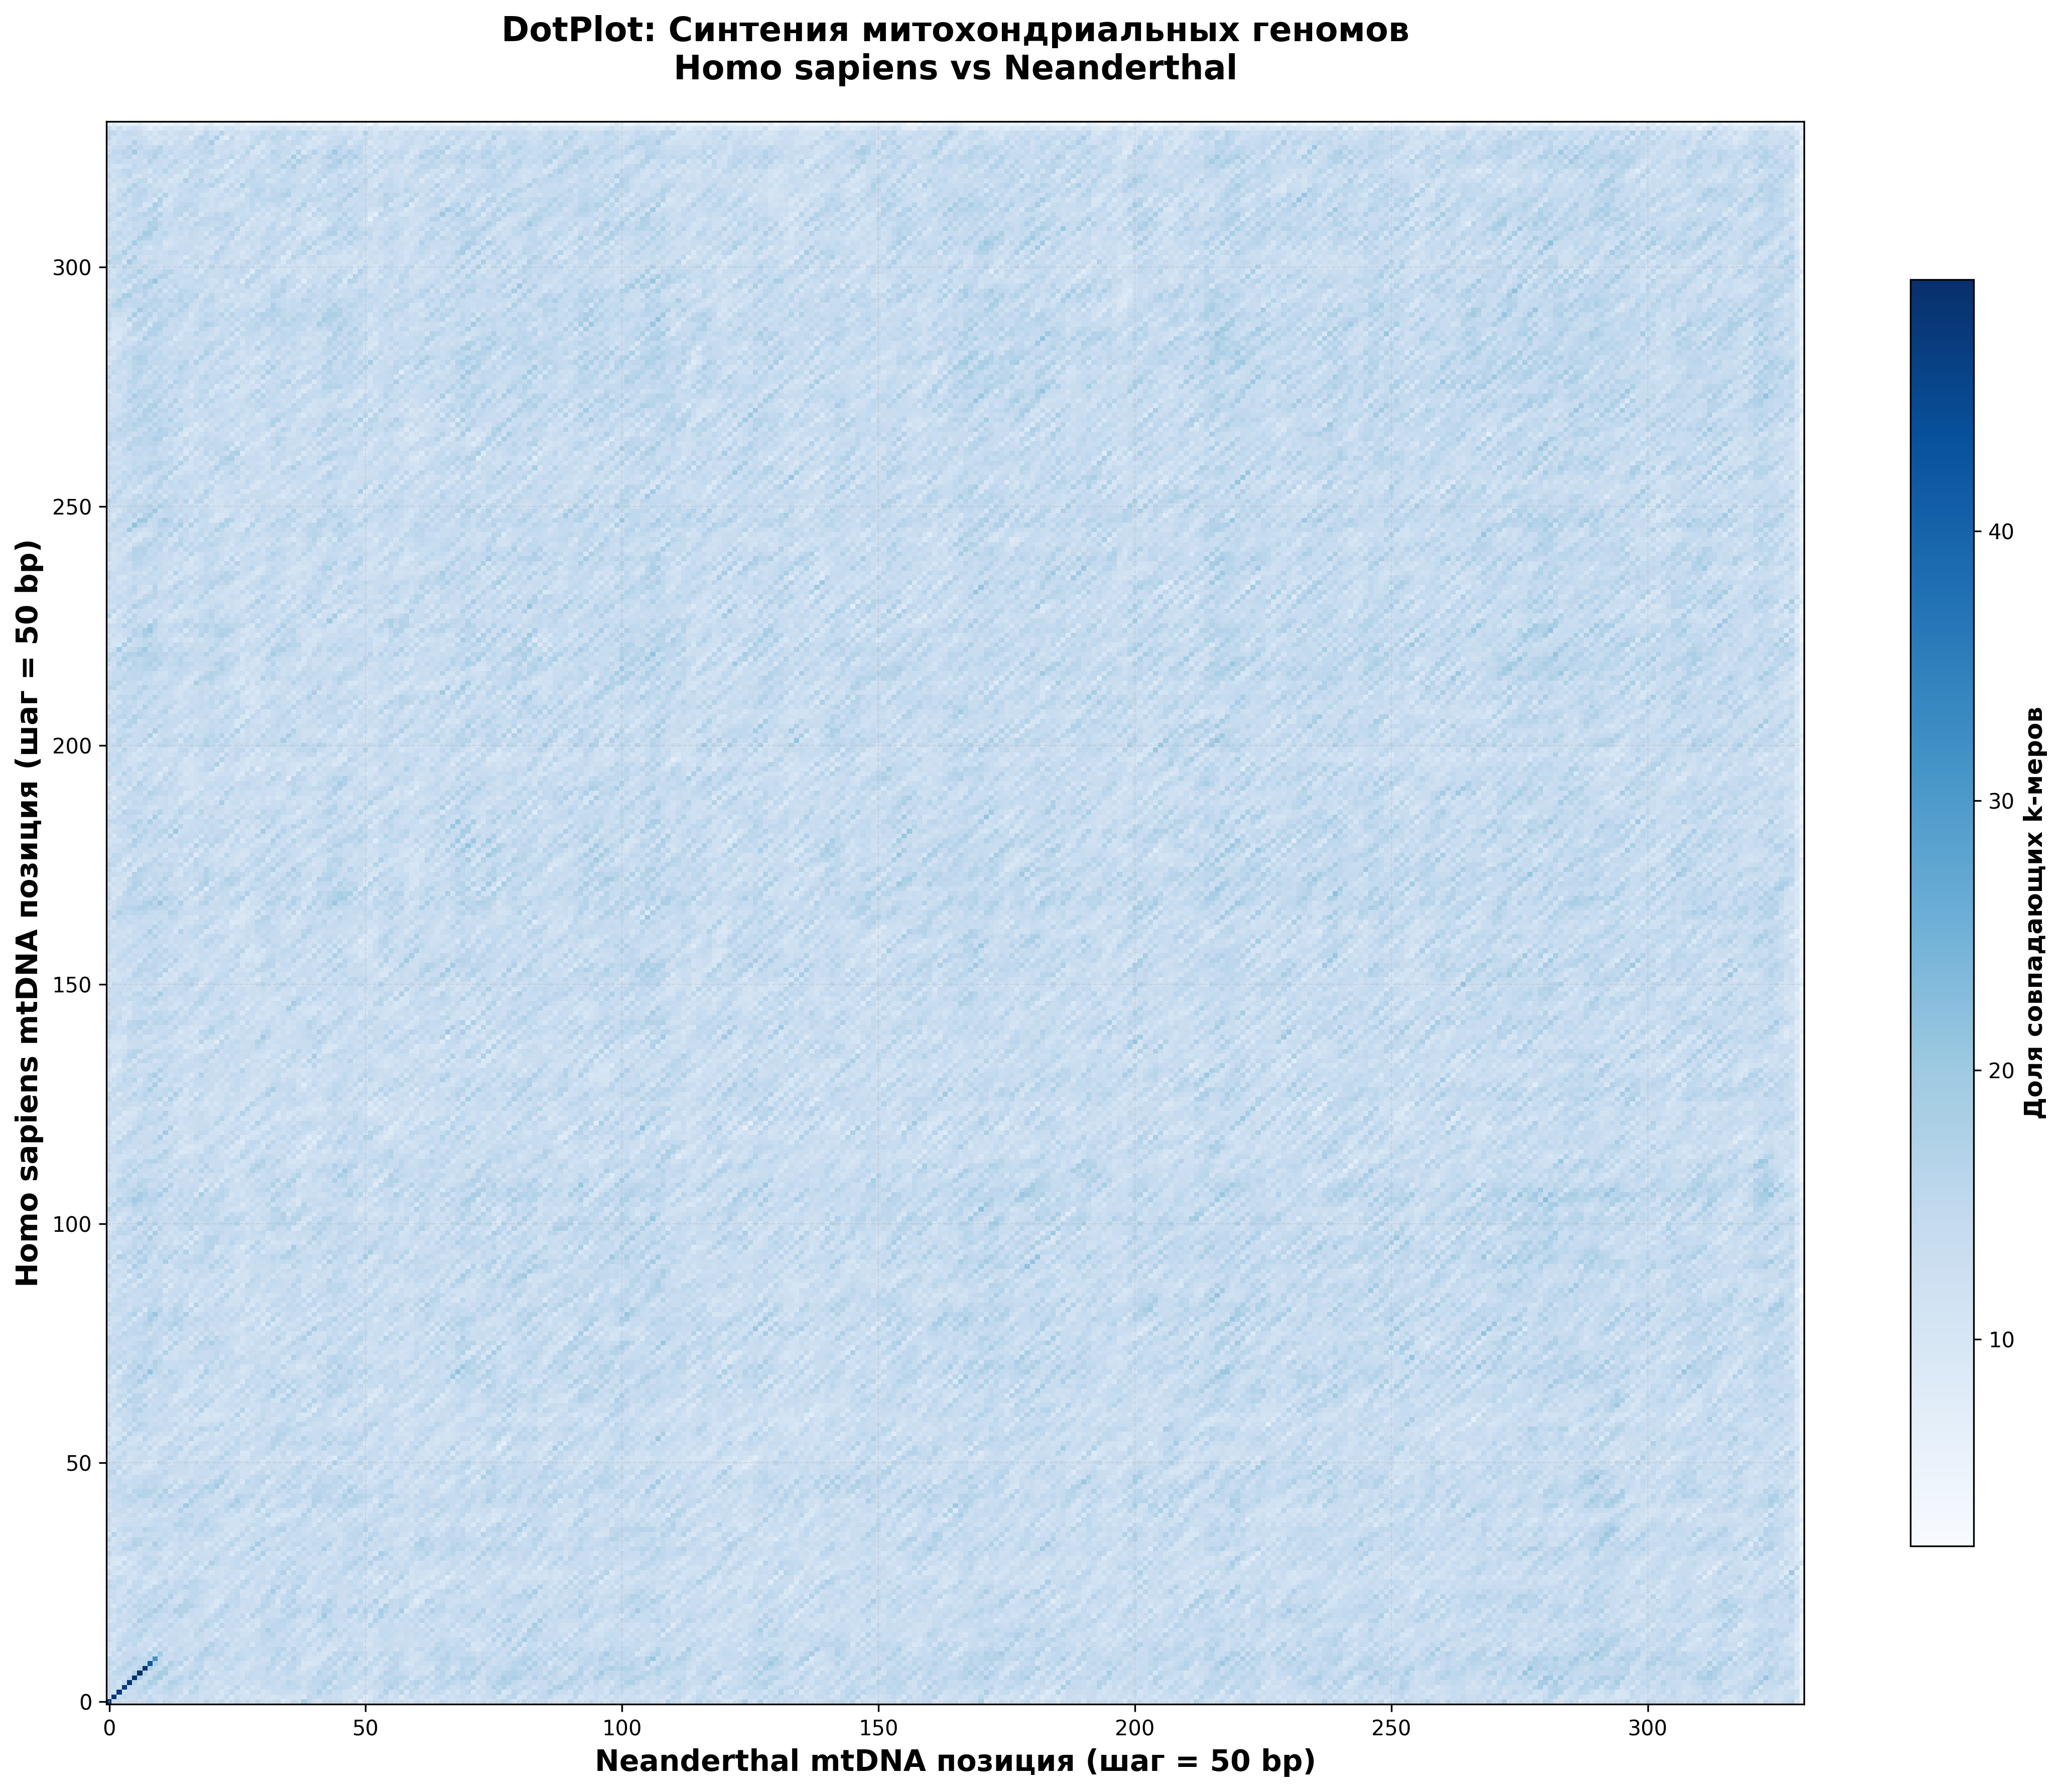

✅ DotPlot сохранен как 'mtDNA_dotplot_biopython.png'
Матрица: (331, 331)
Макс. совпадения: 49.33


In [10]:
"""
DotPlot для митохондриальных геномов человека и неандертальца
Использует Biopython + Matplotlib
"""

from Bio import SeqIO
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl

def read_mtDNA(filename):
    """Чтение митохондриального генома"""
    record = next(SeqIO.parse(filename, 'fasta'))
    return str(record.seq).upper()

def compute_dotplot(seq1, seq2, step=50, k=3):
    """
    Вычисление DotPlot матрицы с окном скольжения
    
    Args:
        seq1, seq2: ДНК последовательности
        step: шаг сэмплирования (для скорости)
        k: размер окна для подсчета совпадений
    """
    n1 = len(seq1) // step
    n2 = len(seq2) // step
    matrix = np.zeros((n1, n2))
    
    for i in range(n1):
        for j in range(n2):
            # Подсчет совпадений в окне k*step
            window1 = seq1[i*step:(i+k)*step]
            window2 = seq2[j*step:(j+k)*step]
            matches = sum(a == b for a, b in zip(window1, window2))
            matrix[i, j] = matches / k
    
    return matrix

# Загрузка последовательностей
print("Загрузка геномов...")
homo_seq = read_mtDNA('homo_sapiens.fasta')
nean_seq = read_mtDNA('neanderthal.fasta')

print(f'Homo sapiens mtDNA: {len(homo_seq):,} bp')
print(f'Neanderthal mtDNA: {len(nean_seq):,} bp')

# Построение DotPlot
print("Вычисление DotPlot...")
dot_matrix = compute_dotplot(homo_seq, nean_seq, step=50, k=3)

# Визуализация
fig, ax = plt.subplots(figsize=(15, 12), dpi=300)
im = ax.imshow(dot_matrix, cmap='Blues', origin='lower', aspect='auto',
               interpolation='nearest')

# Настройка осей
ax.set_xlabel('Neanderthal mtDNA позиция (шаг = 50 bp)', fontsize=14, fontweight='bold')
ax.set_ylabel('Homo sapiens mtDNA позиция (шаг = 50 bp)', fontsize=14, fontweight='bold')
ax.set_title('DotPlot: Синтения митохондриальных геномов\n' + 
             'Homo sapiens vs Neanderthal', fontsize=16, fontweight='bold', pad=20)

# Colorbar
cbar = plt.colorbar(im, ax=ax, shrink=0.8)
cbar.set_label('Доля совпадающих k-меров', fontsize=12, fontweight='bold')

# Сетка для лучшей читаемости
ax.grid(True, alpha=0.3, linestyle='--', linewidth=0.5)

plt.tight_layout()
plt.savefig('mtDNA_dotplot_biopython.png', dpi=300, bbox_inches='tight', 
            facecolor='white')
plt.show()

print("✅ DotPlot сохранен как 'mtDNA_dotplot_biopython.png'")
print(f"Матрица: {dot_matrix.shape}")
print(f"Макс. совпадения: {dot_matrix.max():.2f}")
